In [1]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
# ==============================
# 2. Load Data
# ==============================
# Use your engineered dataset
df = pd.read_csv("final_feature_matrix.csv")

In [3]:
# ==============================
# 3. Select Features (UPDATED)
# ==============================
# Exclude business_id and postal_code (not useful for RF directly)
features = [
    'review_count',
    'review_frequency',
    'avg_sentiment',
    'checkin_count',
    'price_range',
    'takeout',
    'delivery',
    'reservations',
    'outdoor_seating',
    'good_for_kids',
    'competition_density'
]

target = 'stars'

# Keep only relevant columns and drop missing values
df = df[features + [target]].dropna()

# Convert boolean columns to integers if needed
bool_cols = [
    'takeout', 'delivery', 'reservations',
    'outdoor_seating', 'good_for_kids'
]

for col in bool_cols:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

# Ensure everything is numeric
df = df.apply(pd.to_numeric, errors='coerce').dropna()

X = df[features]
y = df[target]


In [4]:
# ==============================
# 4. Train/Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# ==============================
# 5. Train Random Forest
# ==============================
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [6]:
# ==============================
# 6. Predictions
# ==============================
y_pred = rf.predict(X_test)

In [7]:
# ==============================
# 7. Evaluation
# ==============================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R^2: {r2:.3f}")

RMSE: 0.661
R^2: 0.312


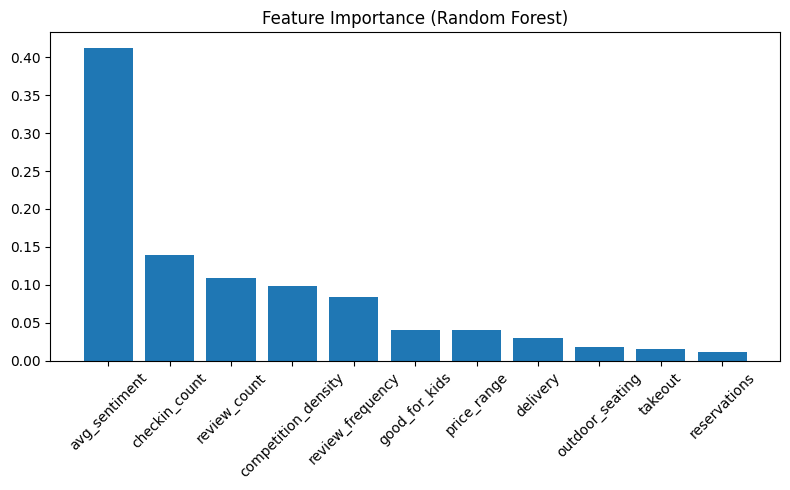

In [8]:
# ==============================
# 8. Feature Importance
# ==============================
importances = rf.feature_importances_
feature_names = X.columns

# Sort
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()

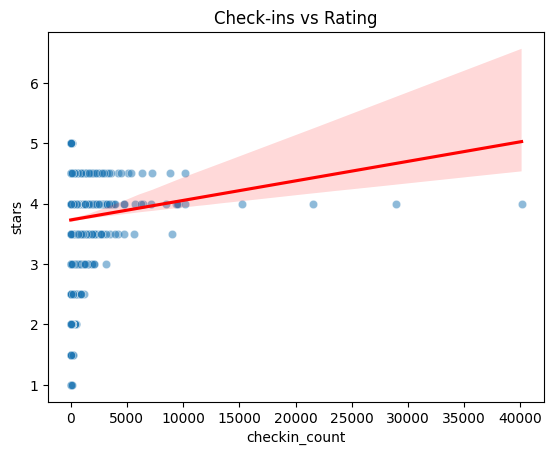

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='checkin_count', y='stars', data=df, alpha=0.5)
sns.regplot(x='checkin_count', y='stars', data=df, scatter=False, color='red')

plt.title("Check-ins vs Rating")
plt.show()